In [1]:
import aim
import matplotlib.pyplot as plt
from plotting_constants import *

In [2]:
import pandas as pd
from aim import Repo
from aim.storage.context import Context

repo = Repo("..")
runs = list(repo.iter_runs())

train_loss_by_run = {
    r.hash: r.get_metric("loss", context=Context({"subset": "train"})).dataframe()[["step", "value"]]
    for r in runs
}

val_loss_by_run = {
    r.hash: r.get_metric("loss", context=Context({"subset": "val"})).dataframe()[["step", "value"]]
    for r in runs
}

single_metrics_df = pd.DataFrame([
    {
        "run_hash": r.hash,
        "experiment": r.experiment,
        "learning_rate": (r.get("run_context") or {}).get("learning_rate"),
        "posttraining_validation_loss": r.get("posttraining_validation_loss"),
        "final_train_loss": float(train_loss_by_run[r.hash]["value"].iloc[-1]),
        "final_val_loss": float(val_loss_by_run[r.hash]["value"].iloc[-1]),
    }
    for r in runs
])

single_metrics_df.head()

,run_hash,experiment,learning_rate,posttraining_validation_loss,final_train_loss,final_val_loss
0,0b75dbb3625c44008ce7a320,learning_rate_search_balanced_pct,0.1000,5.606865,4.443440,5.596445
1,1db5fedfdb68460c8dd3e5a5,learning_rate_search_reduced_pct,0.0220,5.143500,4.774371,5.140829
2,1e9c03f20147493fbbb914c6,learning_rate_search_reduced_pct,0.0050,3.343430,2.598169,3.330781
3,2484174f94c24a438deb30df,learning_rate_search_balanced_pct,0.0140,3.178505,2.293115,3.165385
4,27948c29a3ac487e831a1f6a,learning_rate_search_balanced_pct,0.0185,4.659122,3.591579,4.642914


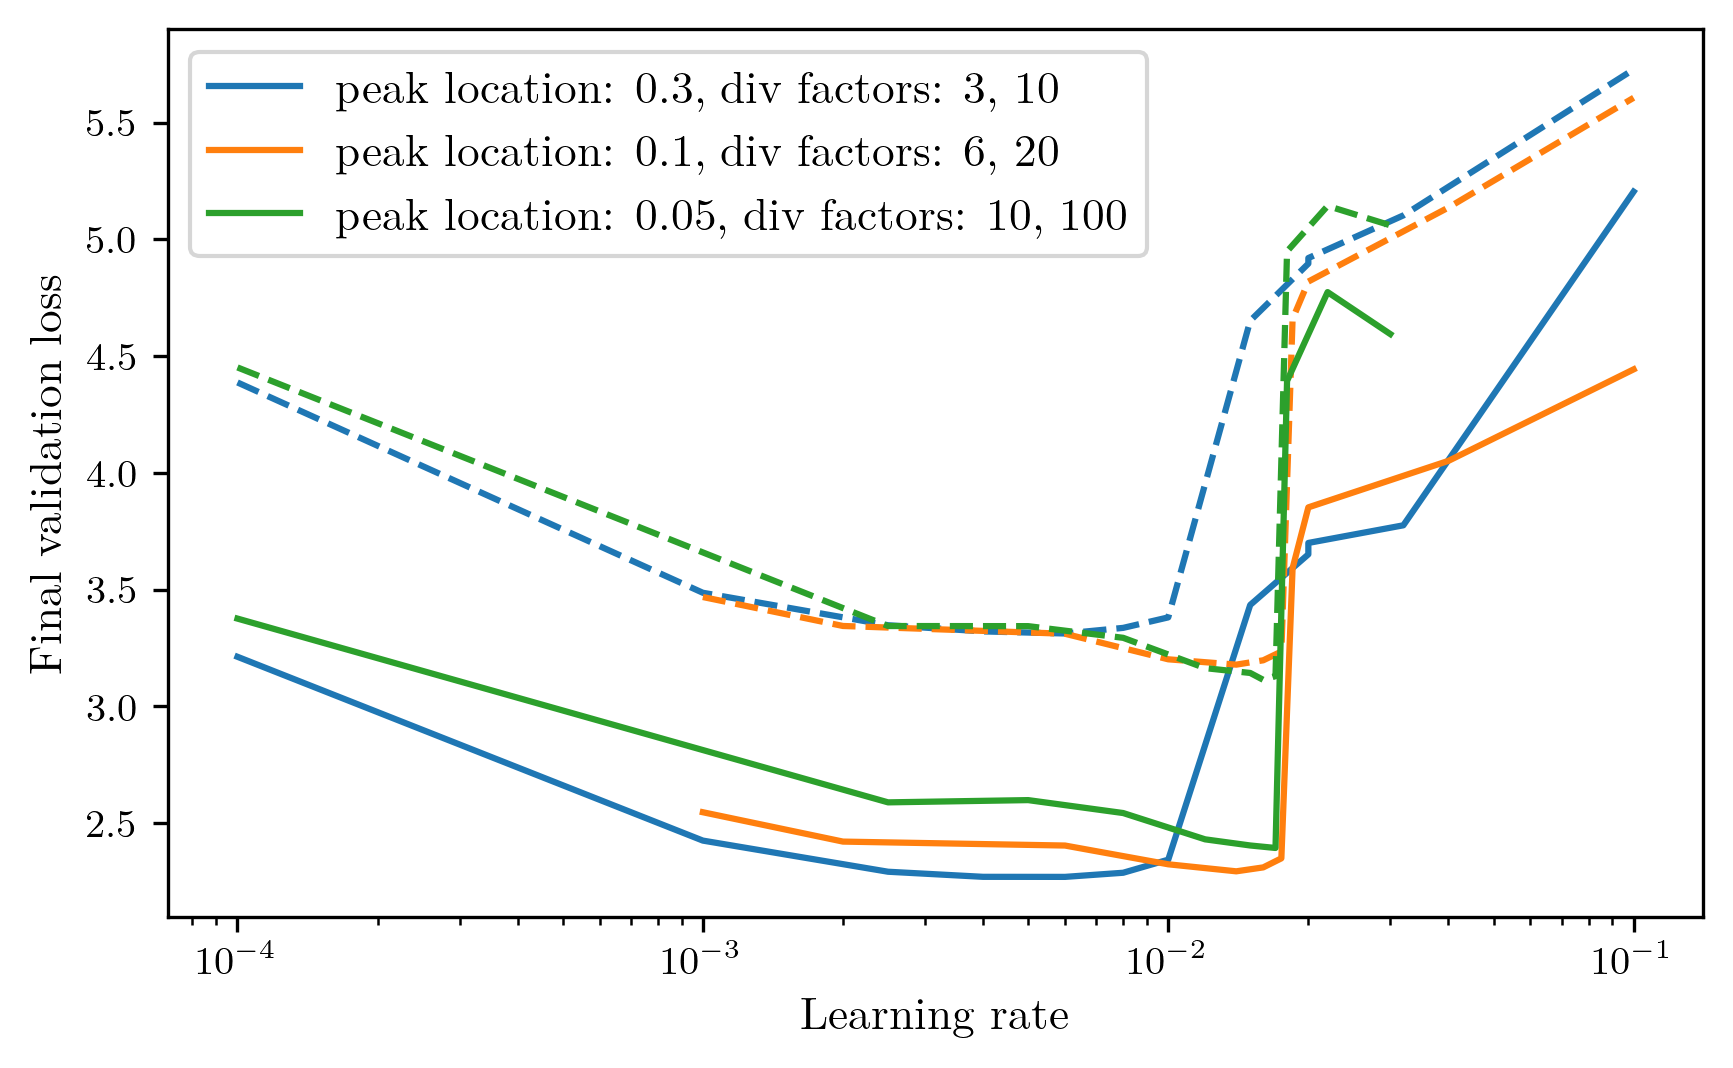

In [3]:
better_name_dict = {"learning_rate_search": "peak location: 0.3, div factors: 3, 10",
                    "learning_rate_search_reduced_pct": "peak location: 0.05, div factors: 10, 100",
                    "learning_rate_search_balanced_pct": "peak location: 0.1, div factors: 6, 20",}

fig, ax = plt.subplots(figsize=big_fig)
for exp, g in single_metrics_df.groupby("experiment"):
    g.sort_values("learning_rate", ascending=True, inplace=True)
    train_line, = ax.plot(g["learning_rate"], g["final_train_loss"], label=better_name_dict[exp])
    ax.plot(g["learning_rate"], g["posttraining_validation_loss"], linestyle="--", color=train_line.get_color())
    
ax.set_xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Final validation loss")
plt.legend()
plt.tight_layout()
plt.savefig("figures/learning_rate_sweeps.png")

In [4]:
single_metrics_df[single_metrics_df["experiment"] == "learning_rate_search_balanced_pct"]["run_hash"]

0     0b75dbb3625c44008ce7a320
3     2484174f94c24a438deb30df
4     27948c29a3ac487e831a1f6a
15    770caacc52d9491ab1c95d6c
19    9260e9f32e184d82b488f89d
22    a6a4da5685e541f0a51e1120
23    a6ad62e5a01e4b5fa41949c1
25    be2b7e5210244ae4907533ac
28    d9f6bb7baf8745f9a46101bc
30    e3179fc2a11e46a1ae01086c
31    f932d08536954459809bef44
Name: run_hash, dtype: object

In [5]:
frames = []
for run_hash in single_metrics_df["run_hash"]:
    run_df = val_loss_by_run[run_hash]
    run_df["final_val_loss"] = single_metrics_df[single_metrics_df["run_hash"] == run_hash]["posttraining_validation_loss"].item()
    run_df["learning_rate"] = single_metrics_df[single_metrics_df["run_hash"] == run_hash]["learning_rate"].item()
    frames.append(run_df)
    
runs_df = pd.concat(frames)

In [6]:
steps = []
correlation = []
for step, df in runs_df.groupby("step"):
    df = df.sort_values("learning_rate")
    steps.append(step)
    correlation.append(df["value"].corr(df["final_val_loss"]))

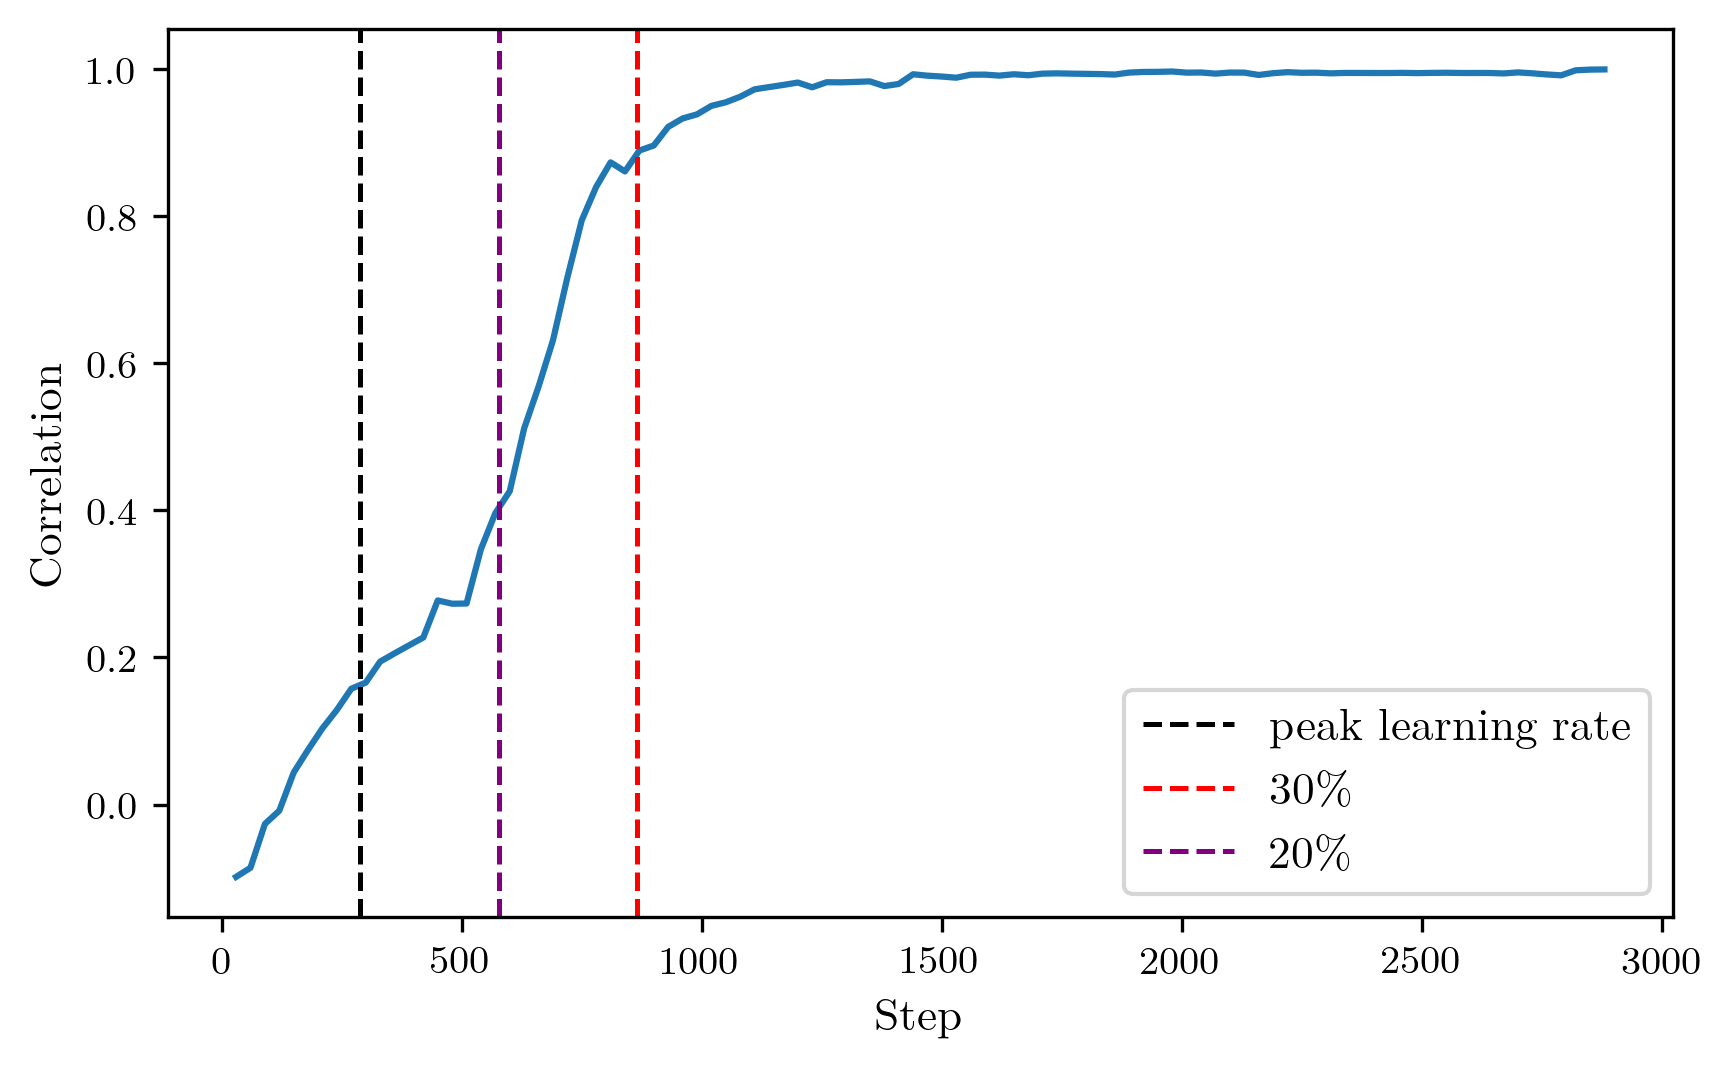

In [7]:
fig, ax = plt.subplots(figsize=big_fig)
ax.plot(steps, correlation)
ax.axvline(2886 * 0.1, color="black", linestyle="--", label="peak learning rate", linewidth=1.2)
ax.axvline(3 * 2886 * 0.1, color="red", linestyle="--", label="30\%", linewidth=1.2)
ax.axvline(2 * 2886 * 0.1, color="purple", linestyle="--", label="20\%", linewidth=1.2)
plt.xlabel("Step")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.savefig("figures/correlation.png")

In [8]:
runs_df[runs_df["step"] == 570].sort_values("value")

,step,value,final_val_loss,learning_rate
18,570,4.182359,3.163644,0.0120
18,570,4.282358,3.113370,0.0160
18,570,4.308964,3.129100,0.0170
18,570,4.319539,3.343430,0.0050
18,570,4.327257,3.142863,0.0150
18,570,4.331004,3.293441,0.0080
18,570,4.338352,3.201328,0.0100
18,570,4.355540,3.310781,0.0060
18,570,4.380778,3.343906,0.0025
18,570,4.426278,3.344161,0.0020


In [9]:
runs_df

,step,value,final_val_loss,learning_rate
0,30,13.841102,5.606865,0.10
1,60,8.622774,5.606865,0.10
2,90,6.254062,5.606865,0.10
3,120,5.764983,5.606865,0.10
4,150,5.763060,5.606865,0.10
...,...,...,...,...
91,2760,3.785069,3.380953,0.01
92,2790,3.790125,3.380953,0.01
93,2820,3.418545,3.380953,0.01
94,2850,3.378344,3.380953,0.01


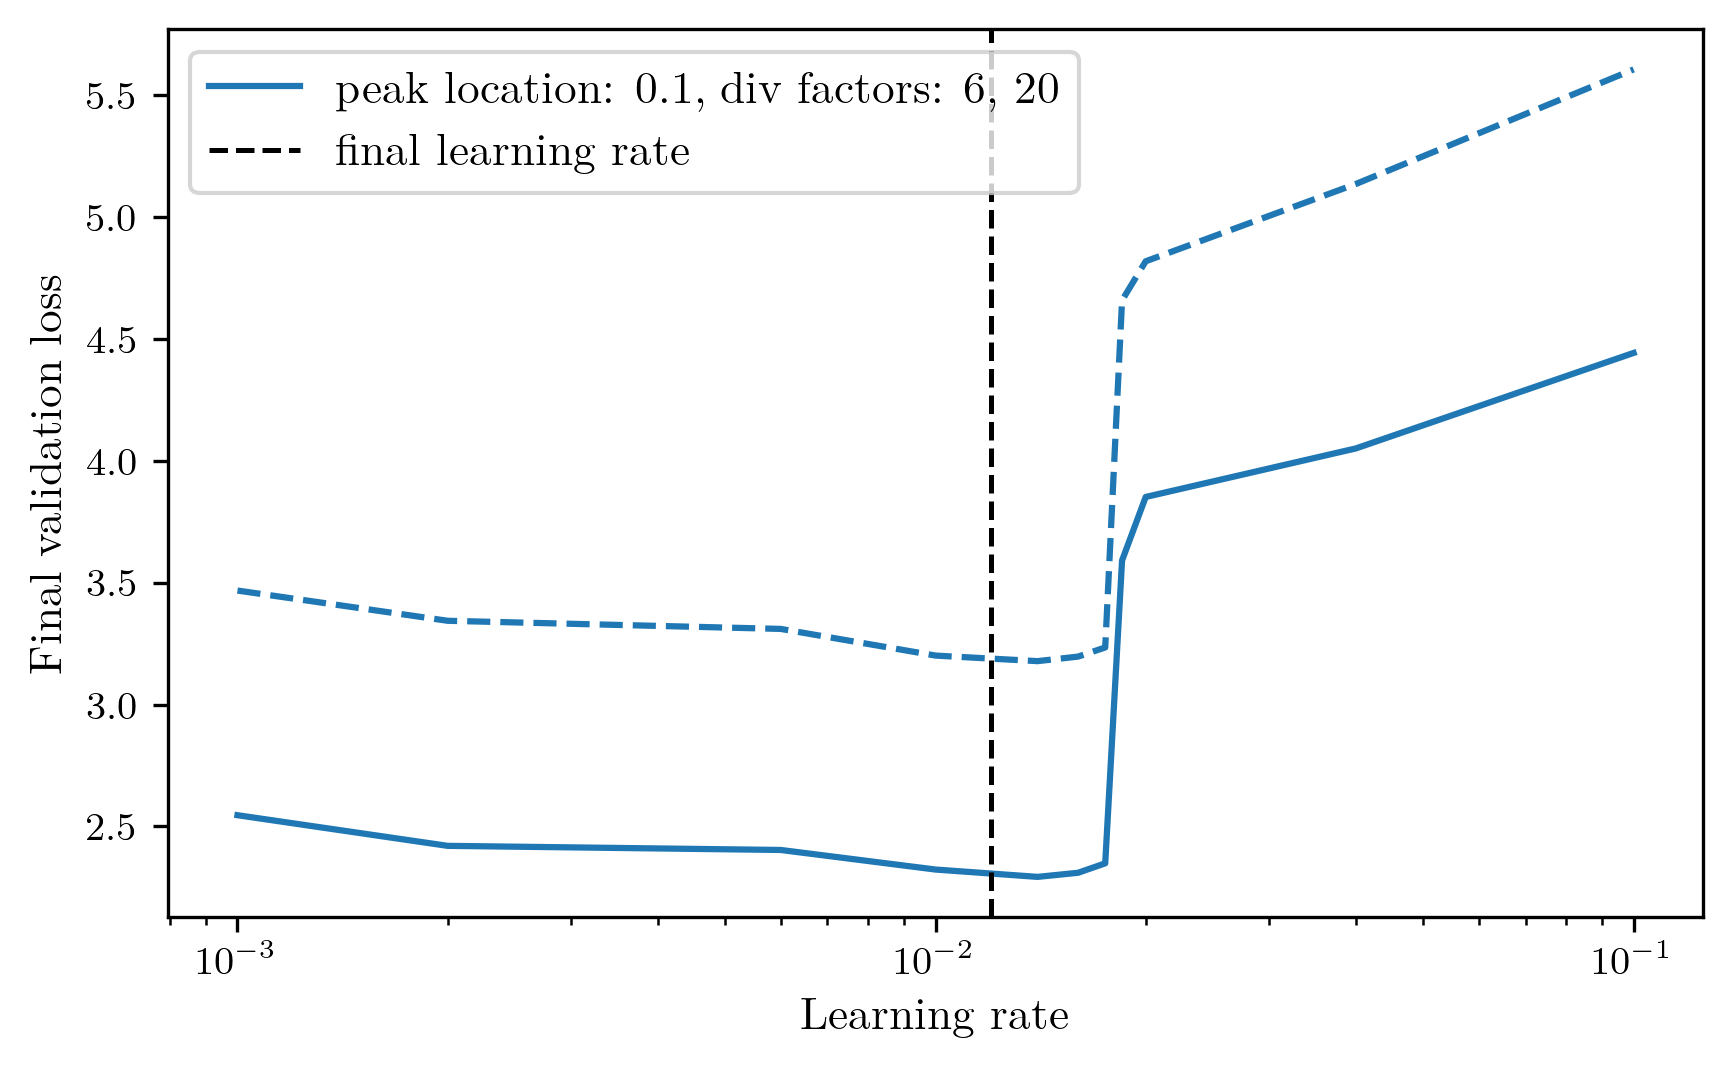

In [10]:
better_name_dict = {"learning_rate_search": "peak location: 0.3, div factors: 3, 10",
                    "learning_rate_search_reduced_pct": "peak location: 0.05, div factors: 10, 100",
                    "learning_rate_search_balanced_pct": "peak location: 0.1, div factors: 6, 20",}

fig, ax = plt.subplots(figsize=big_fig)
for exp, g in single_metrics_df.groupby("experiment"):
    if exp != "learning_rate_search_balanced_pct":
        continue
    g.sort_values("learning_rate", ascending=True, inplace=True)
    train_line, = ax.plot(g["learning_rate"], g["final_train_loss"], label=better_name_dict[exp])
    ax.plot(g["learning_rate"], g["posttraining_validation_loss"], linestyle="--", color=train_line.get_color())
    
ax.set_xscale("log")
ax.axvline(0.012, color="black", linestyle="--", label="final learning rate", linewidth=1.2)
plt.xlabel("Learning rate")
plt.ylabel("Final validation loss")
plt.legend()
plt.tight_layout()
plt.savefig("figures/learning_rate_sweeps_lr_selected.png")